# Wildfires Prediction

Wojciech Pedzinski

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
#importing all necessary packages

In [2]:
#details for wildfire dataset
training_file = "wildfires_training.csv"
test_file = "wildfires_test.csv"
independent_cols = ["year", "temp", "humidity", "rainfall", "drought_code", "buildup_index", "day", 
                    "month", "wind_speed"]
dependent_col = "fire"

#loading our training dataset in from the training file using the pandas library
df_training = pd.read_csv(training_file)
print(df_training.head())
print(df_training.shape)

  fire  year  temp  humidity  rainfall  drought_code  buildup_index  day  \
0   no  2015    28        59       0.0          8.06           3.47    1   
1   no  2010    30        61       1.3          8.17           4.03    2   
2   no  2009    26        83      13.1          8.08           3.59    3   
3   no  2017    25        87       2.5          7.18           2.42    4   
4   no  2014    28        77       0.0         14.98           4.63    5   

   month  wind_speed  
0      6          19  
1      6          13  
2      6          22  
3      6          15  
4      6          18  
(154, 10)


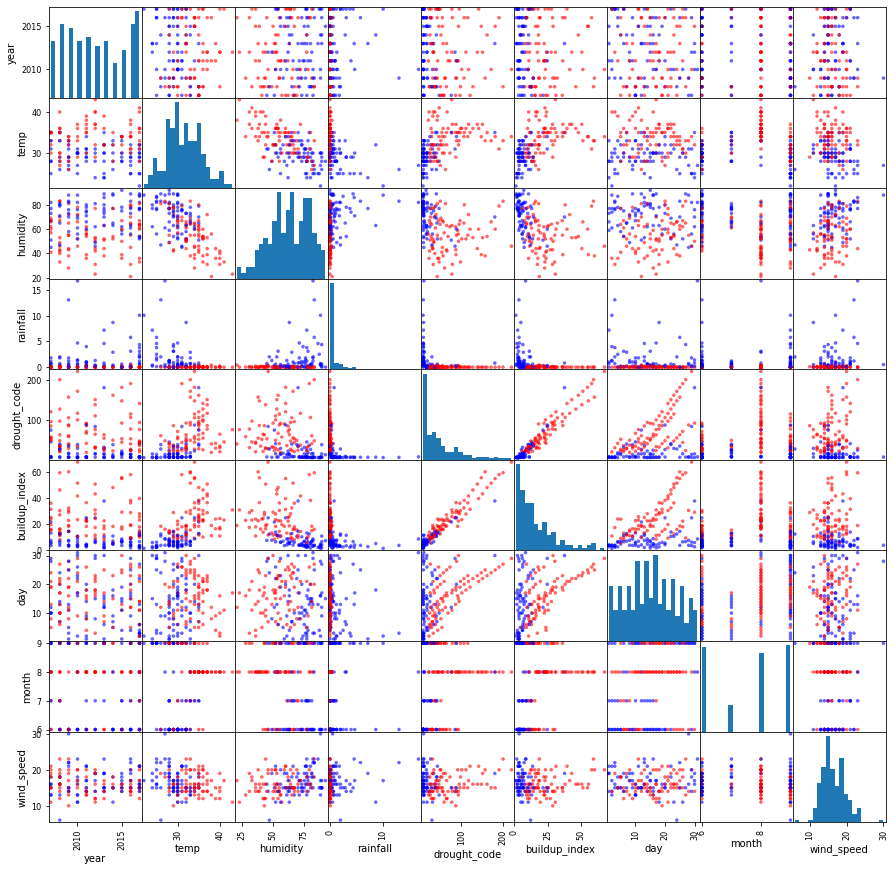

In [3]:
colors = { "yes": "red", "no": "blue"}

#for i in independent_cols:
#    for j in independent_cols:
#        df_training.plot.scatter(x=i, y=j, c=df_training["fire"].apply(lambda x: colors[x]))
#plt.show()


#creating a pairplot using matplotlib
pairplot = pd.plotting.scatter_matrix(df_training, c=df_training["fire"].apply(lambda x: colors[x]), figsize=(15, 15), marker='.',
                                 hist_kwds={'bins': 20}, s=50, alpha=.6)

#plt.savefig("pairplot.png")

In [4]:
#setting up a matrix X containing the independent variables from the training data
X_training = df_training.loc[:,independent_cols]
print(X_training.head())
print(X_training.shape)

   year  temp  humidity  rainfall  drought_code  buildup_index  day  month  \
0  2015    28        59       0.0          8.06           3.47    1      6   
1  2010    30        61       1.3          8.17           4.03    2      6   
2  2009    26        83      13.1          8.08           3.59    3      6   
3  2017    25        87       2.5          7.18           2.42    4      6   
4  2014    28        77       0.0         14.98           4.63    5      6   

   wind_speed  
0          19  
1          13  
2          22  
3          15  
4          18  
(154, 9)


In [5]:
#setting up a vector y containing the "fire" variable for the training data
y_training = df_training.loc[:,dependent_col]
print(y_training.head())
print(y_training.shape)

0    no
1    no
2    no
3    no
4    no
Name: fire, dtype: object
(154,)


In [6]:
#loading our test dataset in from the file wildfires_test.csv
df_test = pd.read_csv(test_file)
print(df_test.head())
print(df_test.shape)

  fire  year  temp  humidity  rainfall  drought_code  buildup_index  day  \
0   no  2015    33        68       4.5          9.12           5.09   19   
1  yes  2009    28        56       0.0         38.17          21.21   12   
2   no  2017    30        64       0.6         15.38           6.24   24   
3   no  2007    23        74       8.3          7.36           2.27   14   
4   no  2017    31        72       0.3         30.47           5.63    7   

   month  wind_speed  
0      6          16  
1      6          18  
2      9          19  
3      9          28  
4      9          17  
(50, 10)


In [7]:
#setting up a matrix X containing the independent variables from the test data
X_test = df_test.loc[:,independent_cols]
print(X_test.head())
print(X_test.shape)

   year  temp  humidity  rainfall  drought_code  buildup_index  day  month  \
0  2015    33        68       4.5          9.12           5.09   19      6   
1  2009    28        56       0.0         38.17          21.21   12      6   
2  2017    30        64       0.6         15.38           6.24   24      9   
3  2007    23        74       8.3          7.36           2.27   14      9   
4  2017    31        72       0.3         30.47           5.63    7      9   

   wind_speed  
0          16  
1          18  
2          19  
3          28  
4          17  
(50, 9)


In [8]:
#setting up a vector y containing the "fire" variable for the training data
y_test = df_test.loc[:,dependent_col]
print(y_test.head())
print(y_test.shape)

0     no
1    yes
2     no
3     no
4     no
Name: fire, dtype: object
(50,)


# Algorithm Testing

# Random Forest

In [9]:
#generating a Random Forest model with default parameters on our dataset
model2 = RandomForestClassifier(random_state=0)

model2.fit(X_training, y_training)

RandomForestClassifier(random_state=0)

In [10]:
#testing model with default parameters
predictions_training2 = model2.predict(X_training)
predictions_test2 = model2.predict(X_test)

accuracy_training2 = metrics.accuracy_score(y_training, predictions_training2)
accuracy_test2 = metrics.accuracy_score(y_test, predictions_test2)

print("Accuracy on training data:",accuracy_training2)
print("Accuracy on test data:",accuracy_test2)

print(classification_report(y_test, predictions_test2))

print(confusion_matrix(y_test, predictions_test2))

Accuracy on training data: 1.0
Accuracy on test data: 0.82
              precision    recall  f1-score   support

          no       0.76      0.86      0.81        22
         yes       0.88      0.79      0.83        28

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.83      0.82      0.82        50

[[19  3]
 [ 6 22]]


In [11]:
#while keeping max_depth at its default value, we create models for a set of 21 values of n_estimators,
#and we calculate training and test accuracy for each one of them
n_values = list(range(10,211,10))
print(n_values)

accuracy_training_n = []
accuracy_test_n = []
for n in n_values:
    model_n = RandomForestClassifier(n_estimators = n, random_state=0)
    model_n.fit(X_training, y_training)

    # compute the predictions for the training and test sets
    predictions_training_n = model_n.predict(X_training)
    predictions_test_n = model_n.predict(X_test)

    # compute the accuracy on the training and test set predictions
    accuracy_training_n.append(metrics.accuracy_score(y_training, predictions_training_n))
    accuracy_test_n.append(metrics.accuracy_score(y_test, predictions_test_n))

print(accuracy_training_n)
print(accuracy_test_n)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210]
[0.9935064935064936, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.86, 0.88, 0.86, 0.84, 0.84, 0.84, 0.84, 0.86, 0.86, 0.82, 0.84, 0.84, 0.82, 0.84, 0.86, 0.84, 0.84, 0.84, 0.84, 0.84, 0.82]


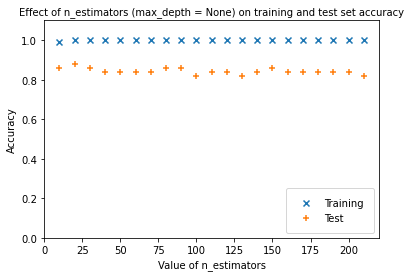

In [12]:
#plotting accuracy for our test and training data
plt.scatter(n_values, accuracy_training_n, marker="x")
plt.scatter(n_values, accuracy_test_n, marker="+")
plt.xlim([0, max(n_values)+10])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of n_estimators")
plt.ylabel("Accuracy")
legend_labels = ["Training", "Test"]
plt.legend(labels=legend_labels, loc=4, borderpad=1)
plt.title("Effect of n_estimators (max_depth = None) on training and test set accuracy", fontsize=10)
plt.show()

In [13]:
#finding the best test set accuracy
np_array = np.array(accuracy_test_n)
max_index = np.unravel_index(np_array.argmax(), np_array.shape)
max_n = n_values[max_index[0]]
print("Max test set accuracy:",np_array.max())
print("Index of max test set accuracy:",max_index)
print("Hyperparameter values: n_estimators =",max_n)

Max test set accuracy: 0.88
Index of max test set accuracy: (1,)
Hyperparameter values: n_estimators = 20


In [14]:
#we create 84 models for a choice of 21 values of n_estimators and 4 values of max_depth,
#and calculate the training and test accuracy for each one of them
m_values = list(range(1,4))
m_values.insert(0,None)
#print(m_values)

accuracy_training_n_m = []
accuracy_test_n_m = []
for j in range(len(m_values)):
    accuracy_training_n_m.append([])
    accuracy_test_n_m.append([])    

    for n in n_values:
        model_n_m = RandomForestClassifier(n_estimators = n, max_depth=m_values[j], random_state=0)
        model_n_m.fit(X_training, y_training)

        # compute the predictions for the training and test sets
        predictions_training_n_m = model_n_m.predict(X_training)
        predictions_test_n_m = model_n_m.predict(X_test)

        # compute the accuracy on the training and test set predictions
        accuracy_training_n_m[j].append(metrics.accuracy_score(y_training, predictions_training_n_m))
        accuracy_test_n_m[j].append(metrics.accuracy_score(y_test, predictions_test_n_m))

    print("m =", m_values[j], "training", accuracy_training_n_m[j], "\n")
    print("m =", m_values[j], "test", accuracy_test_n_m[j], "\n")

m = None training [0.9935064935064936, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0] 

m = None test [0.86, 0.88, 0.86, 0.84, 0.84, 0.84, 0.84, 0.86, 0.86, 0.82, 0.84, 0.84, 0.82, 0.84, 0.86, 0.84, 0.84, 0.84, 0.84, 0.84, 0.82] 

m = 1 training [0.8961038961038961, 0.8896103896103896, 0.9025974025974026, 0.9025974025974026, 0.8961038961038961, 0.8961038961038961, 0.8896103896103896, 0.8896103896103896, 0.8896103896103896, 0.8896103896103896, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961, 0.8961038961038961] 

m = 1 test [0.82, 0.8, 0.84, 0.84, 0.82, 0.84, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82] 

m = 2 training [0.922077922077922, 0.922077922077922, 0.9155844155844156, 0.9155844155844156, 0.9155844155844156, 0.9155844155844156, 0.915

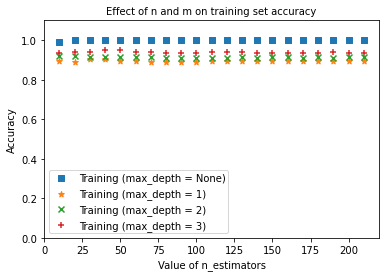

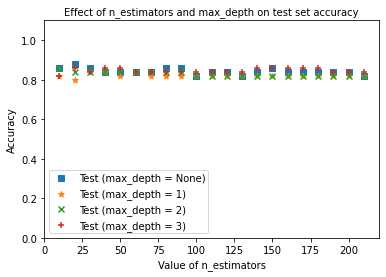

In [15]:
#plotting accuracy on the training set
plt.scatter(n_values, accuracy_training_n_m[0], marker="s")
plt.scatter(n_values, accuracy_training_n_m[1], marker="*")
plt.scatter(n_values, accuracy_training_n_m[2], marker="x")
plt.scatter(n_values, accuracy_training_n_m[3], marker="+")
plt.xlim([0, max(n_values)+10])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of n_estimators")
plt.ylabel("Accuracy")
legend_labels = ["Training (max_depth = None)", "Training (max_depth = 1)", "Training (max_depth = 2)", "Training (max_depth = 3)"]
plt.legend(labels=legend_labels, borderpad=0.2)
plt.title("Effect of n and m on training set accuracy", fontsize=10)
plt.show()

#plotting accuracy on the test set
plt.scatter(n_values, accuracy_test_n_m[0], marker="s")
plt.scatter(n_values, accuracy_test_n_m[1], marker="*")
plt.scatter(n_values, accuracy_test_n_m[2], marker="x")
plt.scatter(n_values, accuracy_test_n_m[3], marker="+")
plt.xlim([0, max(n_values)+10])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of n_estimators")
plt.ylabel("Accuracy")
legend_labels = ["Test (max_depth = None)", "Test (max_depth = 1)", "Test (max_depth = 2)", "Test (max_depth = 3)"]
plt.legend(labels=legend_labels, borderpad=0.2)
plt.title("Effect of n_estimators and max_depth on test set accuracy", fontsize=10)
plt.show()

In [16]:
#finding the best test set accuracy
np_array = np.array(accuracy_test_n_m)
max_index = np.unravel_index(np_array.argmax(), np_array.shape)

n_max = n_values[max_index[1]]
m_max = m_values[max_index[0]]

print("Max test set accuracy:", np_array.max())
print("Index of max test set accuracy:", max_index)
print("Hyperparameter values: n_estimators =", n_max, ", max_depth =", m_max)

Max test set accuracy: 0.88
Index of max test set accuracy: (0, 1)
Hyperparameter values: n_estimators = 20 , max_depth = None


In [17]:
#generating new model based on tuned parameters
model2 = RandomForestClassifier(n_estimators = n_max, max_depth=m_max, random_state=0)
model2.fit(X_training, y_training)

RandomForestClassifier(n_estimators=20, random_state=0)

In [18]:
#testing on model with tuned parameters
predictions_training2 = model2.predict(X_training)
predictions_test2 = model2.predict(X_test)
accuracy_training2 = metrics.accuracy_score(y_training, predictions_training2)
accuracy_test2 = metrics.accuracy_score(y_test, predictions_test2)

print("Accuracy on training data:",accuracy_training2)
print("Accuracy on test data:",accuracy_test2)

print(classification_report(y_test, predictions_test2))

print(confusion_matrix(y_test, predictions_test2))

Accuracy on training data: 1.0
Accuracy on test data: 0.88
              precision    recall  f1-score   support

          no       0.81      0.95      0.88        22
         yes       0.96      0.82      0.88        28

    accuracy                           0.88        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.89      0.88      0.88        50

[[21  1]
 [ 5 23]]


# RBF SVM

In [19]:
#scaling our data
scaler = StandardScaler()
X_training = scaler.fit_transform(X_training)
X_test = scaler.transform(X_test)

#generating model based on default parameters
model1 = svm.SVC(kernel='rbf')
model1.fit(X_training, y_training)


SVC()

In [20]:
#testing on default RBF SVM
predictions_training1 = model1.predict(X_training)
predictions_test1 = model1.predict(X_test)

accuracy_training1 = metrics.accuracy_score(y_training, predictions_training1)
accuracy_test1 = metrics.accuracy_score(y_test, predictions_test1)

print("Accuracy on training data:",accuracy_training1)
print("Accuracy on test data:",accuracy_test1)

print(classification_report(y_test, predictions_test1))

print(confusion_matrix(y_test, predictions_test1))

Accuracy on training data: 0.935064935064935
Accuracy on test data: 0.8
              precision    recall  f1-score   support

          no       0.75      0.82      0.78        22
         yes       0.85      0.79      0.81        28

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50

[[18  4]
 [ 6 22]]


In [21]:
#while keeping C at its default value,
#we generate test and training data accuracy for 21 models with different values of gamma selected based on a logarithmic scale
g_values = np.logspace(-4, 1, 21, endpoint = True) 
print(g_values)

accuracy_training_g = []
accuracy_test_g = []
for g in g_values:
    model_g = svm.SVC(kernel='rbf', gamma = g)
    model_g.fit(X_training, y_training)

    # compute the predictions for the training and test sets
    predictions_training_g = model_g.predict(X_training)
    predictions_test_g = model_g.predict(X_test)

    # compute the accuracy on the training and test set predictions
    accuracy_training_g.append(metrics.accuracy_score(y_training, predictions_training_g))
    accuracy_test_g.append(metrics.accuracy_score(y_test, predictions_test_g))

print(accuracy_training_g)
print(accuracy_test_g)

[1.00000000e-04 1.77827941e-04 3.16227766e-04 5.62341325e-04
 1.00000000e-03 1.77827941e-03 3.16227766e-03 5.62341325e-03
 1.00000000e-02 1.77827941e-02 3.16227766e-02 5.62341325e-02
 1.00000000e-01 1.77827941e-01 3.16227766e-01 5.62341325e-01
 1.00000000e+00 1.77827941e+00 3.16227766e+00 5.62341325e+00
 1.00000000e+01]
[0.512987012987013, 0.512987012987013, 0.512987012987013, 0.6948051948051948, 0.8311688311688312, 0.7922077922077922, 0.8181818181818182, 0.8311688311688312, 0.8571428571428571, 0.8571428571428571, 0.8831168831168831, 0.9025974025974026, 0.922077922077922, 0.9285714285714286, 0.9415584415584416, 0.9545454545454546, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.56, 0.56, 0.56, 0.6, 0.74, 0.7, 0.74, 0.74, 0.74, 0.76, 0.8, 0.8, 0.8, 0.82, 0.8, 0.82, 0.7, 0.62, 0.56, 0.58, 0.56]


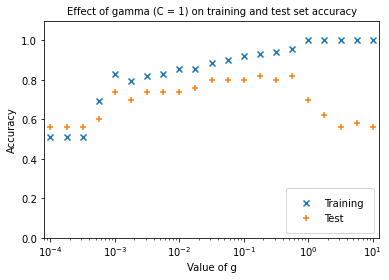

In [22]:
#plotting training and test set accuracy
plt.scatter(g_values, accuracy_training_g, marker="x")
plt.scatter(g_values, accuracy_test_g, marker="+")
plt.xlim([min(g_values)*0.8, max(g_values)/0.8])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of g")
plt.ylabel("Accuracy")
plt.xscale("log")
legend_labels = ["Training", "Test"]
plt.legend(labels=legend_labels, loc=4, borderpad=1)
plt.title("Effect of gamma (C = 1) on training and test set accuracy", fontsize=10)
plt.show()

In [23]:
#finding the best test set accuracy
np_array = np.array(accuracy_test_g)
max_index = np.unravel_index(np_array.argmax(), np_array.shape)
max_g = g_values[max_index[0]]
print("Max test set accuracy:",np_array.max())
print("Index of max test set accuracy:",max_index)
print("Hyperparameter values: gamma =",max_g)

Max test set accuracy: 0.82
Index of max test set accuracy: (13,)
Hyperparameter values: gamma = 0.1778279410038923


In [24]:
#generating 84 models for a choice of 21 values of gamma and 4 values of C,
#both of these hyperparameters are taken from a logarithmic scale
#we generate test and training data accuracies for each model

c_values = np.logspace(2, 5, 4, endpoint=True)
# print(c_values)

accuracy_training_g_c = []
accuracy_test_g_c = []
for j in range(len(c_values)):
    accuracy_training_g_c.append([])
    accuracy_test_g_c.append([])    

    for g in g_values:
        model_g_c = svm.SVC(kernel='rbf', gamma=g, C=c_values[j])
        model_g_c.fit(X_training, y_training)

        # compute the predictions for the training and test sets
        predictions_training_g_c = model_g_c.predict(X_training)
        predictions_test_g_c = model_g_c.predict(X_test)

        # compute the accuracy on the training and test set predictions
        accuracy_training_g_c[j].append(metrics.accuracy_score(y_training, predictions_training_g_c))
        accuracy_test_g_c[j].append(metrics.accuracy_score(y_test, predictions_test_g_c))

    print("c =", c_values[j], "training", accuracy_training_g_c[j], "\n")
    print("c =", c_values[j], "test", accuracy_test_g_c[j], "\n")

c = 100.0 training [0.8506493506493507, 0.8376623376623377, 0.8636363636363636, 0.8766233766233766, 0.8961038961038961, 0.9090909090909091, 0.9090909090909091, 0.9285714285714286, 0.935064935064935, 0.948051948051948, 0.961038961038961, 0.974025974025974, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0] 

c = 100.0 test [0.74, 0.76, 0.82, 0.82, 0.82, 0.82, 0.82, 0.84, 0.84, 0.84, 0.8, 0.8, 0.7, 0.62, 0.68, 0.68, 0.66, 0.62, 0.58, 0.58, 0.56] 

c = 1000.0 training [0.8961038961038961, 0.9025974025974026, 0.9025974025974026, 0.9090909090909091, 0.9155844155844156, 0.9285714285714286, 0.935064935064935, 0.9545454545454546, 0.9545454545454546, 0.9805194805194806, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0] 

c = 1000.0 test [0.82, 0.8, 0.82, 0.86, 0.88, 0.84, 0.86, 0.82, 0.86, 0.84, 0.82, 0.8, 0.72, 0.62, 0.68, 0.68, 0.66, 0.62, 0.58, 0.58, 0.56] 

c = 10000.0 training [0.9155844155844156, 0.922077922077922, 0.9155844155844156, 0.9285714285714286, 0.9415584415584416, 0.9675324675324

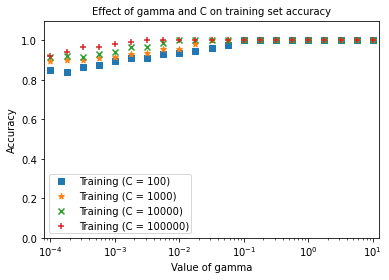

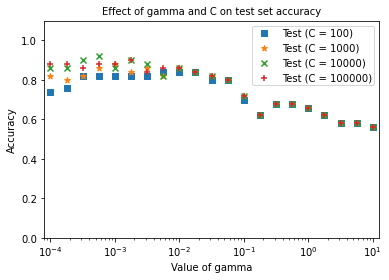

In [25]:
#plotting accuracy on the training set
plt.scatter(g_values, accuracy_training_g_c[0], marker="s")
plt.scatter(g_values, accuracy_training_g_c[1], marker="*")
plt.scatter(g_values, accuracy_training_g_c[2], marker="x")
plt.scatter(g_values, accuracy_training_g_c[3], marker="+")
plt.xlim([min(g_values)*0.8, max(g_values)/0.8])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of gamma")
plt.ylabel("Accuracy")
plt.xscale("log")
legend_labels = ["Training (C = 100)", "Training (C = 1000)", "Training (C = 10000)", "Training (C = 100000)"]
plt.legend(labels=legend_labels, borderpad=0.2)
plt.title("Effect of gamma and C on training set accuracy", fontsize=10)
plt.show()

#plotting accuracy on the test set
plt.scatter(g_values, accuracy_test_g_c[0], marker="s")
plt.scatter(g_values, accuracy_test_g_c[1], marker="*")
plt.scatter(g_values, accuracy_test_g_c[2], marker="x")
plt.scatter(g_values, accuracy_test_g_c[3], marker="+")
plt.xlim([min(g_values)*0.8, max(g_values)/0.8])
plt.ylim([0.0, 1.1])
plt.xlabel("Value of gamma")
plt.ylabel("Accuracy")
plt.xscale("log")
legend_labels = ["Test (C = 100)", "Test (C = 1000)", "Test (C = 10000)", "Test (C = 100000)"]
plt.legend(labels=legend_labels, borderpad=0.2)
plt.title("Effect of gamma and C on test set accuracy", fontsize=10)
plt.show()

In [26]:
#finding the best test set accuracy
np_array = np.array(accuracy_test_g_c)
max_index = np.unravel_index(np_array.argmax(), np_array.shape)
max_c = c_values[max_index[0]]
max_g = g_values[max_index[1]]
print("Max test set accuracy:",np_array.max())
print("Index of max test set accuracy:",max_index)
print("Hyperparameter values: C =",max_c,", gamma =",max_g) 

Max test set accuracy: 0.92
Index of max test set accuracy: (2, 3)
Hyperparameter values: C = 10000.0 , gamma = 0.0005623413251903491


In [27]:
#scaler = StandardScaler()
#X_training = scaler.fit_transform(X_training)
#X_test = scaler.transform(X_test)

#generating our model on the best values for gamma and C
model1 = svm.SVC(kernel='rbf', gamma=max_g, C=max_c)
model1.fit(X_training, y_training)

SVC(C=10000.0, gamma=0.0005623413251903491)

In [28]:
#testing on tuned parameters
predictions_training1 = model1.predict(X_training)
predictions_test1 = model1.predict(X_test)

accuracy_training1 = metrics.accuracy_score(y_training, predictions_training1)
accuracy_test1 = metrics.accuracy_score(y_test, predictions_test1)

print("Accuracy on training data:",accuracy_training1)
print("Accuracy on test data:",accuracy_test1)

print(classification_report(y_test, predictions_test1))

print(confusion_matrix(y_test, predictions_test1))

Accuracy on training data: 0.9285714285714286
Accuracy on test data: 0.92
              precision    recall  f1-score   support

          no       0.88      0.95      0.91        22
         yes       0.96      0.89      0.93        28

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50

[[21  1]
 [ 3 25]]
